In [9]:
#!/usr/bin/env python3
"""
Seizure Epoch Analysis - Data Loading Functions
Extract raw bandpower around seizure events from iEEG data.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pynwb import NWBHDF5IO
from pathlib import Path
from typing import List, Dict, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_PATH = Path('/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB')

# Frequency bands and their ranges (Hz)
BAND_NAMES = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma']
BAND_RANGES = {
    'delta': (1.0, 4.0),
    'theta': (4.0, 8.0),
    'alpha': (8.0, 12.0),
    'beta': (15.0, 25.0),
    'gamma': (25.0, 70.0),
    'high_gamma': (70.0, 170.0)
}

# Calculate bandwidth for each band
BAND_BANDWIDTHS = {
    'delta': 3,       # 4 - 1 = 3 Hz
    'theta': 4,       # 8 - 4 = 4 Hz
    'alpha': 4,       # 12 - 8 = 4 Hz
    'beta': 10,       # 25 - 15 = 10 Hz
    'gamma': 45,      # 70 - 25 = 45 Hz
    'high_gamma': 100 # 170 - 70 = 100 Hz
}

TOTAL_BANDWIDTH = sum(BAND_BANDWIDTHS.values())  # 166 Hz

# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_file_metadata(metadata_csv_path: str = None) -> pd.DataFrame:
    """
    Load the file metadata CSV.
    
    Args:
        metadata_csv_path: Path to the metadata CSV file. If None, looks for it in BASE_PATH.
    
    Returns:
        DataFrame with file metadata
    """
    if metadata_csv_path is None:
        # Look for CSV in base path
        metadata_csv_path = BASE_PATH / 'file_metadata.csv'
    
    metadata = pd.read_csv(metadata_csv_path)
    
    # Convert datetime columns
    metadata['start_datetime'] = pd.to_datetime(metadata['start_datetime'])
    metadata['end_datetime'] = pd.to_datetime(metadata['end_datetime'])
    
    # Only keep rows with preprocessed files
    metadata = metadata[metadata['has_preprocessed'] == True].copy()
    
    print(f"Loaded metadata for {len(metadata)} preprocessed files")
    
    return metadata


def get_all_subjects_with_seizures(file_metadata: pd.DataFrame) -> List[Tuple[str, str]]:
    """
    Find all subject-session pairs that have both preprocessed files and seizure data.
    
    Returns:
        List of (subject_id, session_id) tuples
    """
    subjects_sessions = []
    
    # Get unique subject-session combinations from metadata
    unique_sessions = file_metadata[['sub_id', 'ses_id']].drop_duplicates()
    
    for _, row in unique_sessions.iterrows():
        subject_id = row['sub_id'].replace('sub-', '')
        session_id = row['ses_id'].replace('ses-', '')
        
        # Check if seizure file exists
        ehr_dir = BASE_PATH / f'sub-{subject_id}' / f'ses-{session_id}' / 'ehr'
        seizure_file = ehr_dir / f'sub-{subject_id}_ses-{session_id}_seizures.csv'
        
        if seizure_file.exists():
            subjects_sessions.append((subject_id, session_id))
            
            # Count files for this session
            n_files = len(file_metadata[
                (file_metadata['sub_id'] == f'sub-{subject_id}') & 
                (file_metadata['ses_id'] == f'ses-{session_id}')
            ])
            print(f"Found: sub-{subject_id}, ses-{session_id} ({n_files} files)")
    
    return subjects_sessions


def load_seizure_times(subject_id: str, session_id: str) -> pd.DataFrame:
    """Load seizure times from EHR folder."""
    ehr_dir = BASE_PATH / f'sub-{subject_id}' / f'ses-{session_id}' / 'ehr'
    seizure_file = ehr_dir / f'sub-{subject_id}_ses-{session_id}_seizures.csv'
    
    if not seizure_file.exists():
        raise FileNotFoundError(f"Seizure file not found: {seizure_file}")
    
    # Load seizure times
    seizures = pd.read_csv(seizure_file)
    seizures['date'] = pd.to_datetime(seizures['date'])
    
    # Filter for this specific subject and session
    seizures = seizures[(seizures['sub_id'] == f'sub-{subject_id}') & 
                        (seizures['ses_id'] == f'ses-{session_id}')]
    
    return seizures


def get_relevant_files(file_metadata: pd.DataFrame,
                      subject_id: str,
                      session_id: str,
                      seizure_df: pd.DataFrame,
                      window_minutes: int = 7) -> List[Path]:
    """
    Get only the NWB files that overlap with seizure windows.
    
    Args:
        file_metadata: DataFrame with file metadata
        subject_id: Subject ID
        session_id: Session ID
        seizure_df: DataFrame with seizure times
        window_minutes: Window size around seizures
    
    Returns:
        List of Path objects for relevant NWB files
    """
    # Filter metadata for this session
    session_files = file_metadata[
        (file_metadata['sub_id'] == f'sub-{subject_id}') & 
        (file_metadata['ses_id'] == f'ses-{session_id}')
    ].copy()
    
    if len(session_files) == 0:
        return []
    
    relevant_files = []
    
    for seizure_idx, seizure_row in seizure_df.iterrows():
        seizure_time = seizure_row['date']
        
        # Calculate window
        window_start = seizure_time - pd.Timedelta(minutes=window_minutes)
        window_end = seizure_time + pd.Timedelta(minutes=window_minutes)
        
        # Find files that overlap with this window
        overlapping = session_files[
            (session_files['start_datetime'] <= window_end) &
            (session_files['end_datetime'] >= window_start)
        ]
        
        for _, file_row in overlapping.iterrows():
            file_path = Path(file_row['preprocessed_file_path'])
            if file_path not in relevant_files:
                relevant_files.append(file_path)
    
    return sorted(relevant_files)


def load_electrode_labels(nwb_file_path: Path) -> Dict[int, str]:
    """Load electrode labels from NWB file."""
    electrode_labels = {}
    try:
        with NWBHDF5IO(str(nwb_file_path), 'r') as io:
            nwb = io.read()
            electrodes_df = nwb.electrodes.to_dataframe()
            
            if 'Desikan_Killiany_cathode' in electrodes_df.columns:
                for idx, row in electrodes_df.iterrows():
                    label = row['Desikan_Killiany_cathode']
                    if pd.isna(label) or label == '' or label == 'nan':
                        electrode_labels[idx] = f'Ch{idx}'
                    else:
                        electrode_labels[idx] = str(label)
    except Exception as e:
        print(f"Warning: Could not load electrode labels: {e}")
    
    return electrode_labels


def filter_valid_channels(electrode_labels: Dict[int, str]) -> Dict[int, str]:
    """Filter out channels with 'unknown' or 'white-matter' in their labels."""
    valid_labels = {}
    
    for ch_idx, label in electrode_labels.items():
        label_lower = label.lower()
        if 'unknown' not in label_lower and 'white-matter' not in label_lower and 'white matter' not in label_lower:
            valid_labels[ch_idx] = label
    
    return valid_labels


def extract_raw_bandpower_seizure_epochs(nwb_file: Path, 
                                         seizure_df: pd.DataFrame,
                                         valid_channel_indices: set,
                                         window_minutes: int = 7) -> Dict:
    """
    Extract RAW bandpower data (per channel, per band) around seizures.
    NO aggregation happens here - that's done in plotting.
    
    Args:
        nwb_file: Path to NWB file
        seizure_df: DataFrame with seizure times
        valid_channel_indices: Set of valid channel indices
        window_minutes: Window size around seizures
    
    Returns:
        dict: {seizure_idx: {'times': [time_arrays], 
                             'bandpower': [power_arrays]}}
        where power_arrays have shape (timepoints, channels, bands)
    """
    seizure_data = {}
    
    try:
        with NWBHDF5IO(str(nwb_file), 'r') as io:
            nwb = io.read()
            
            # Get session start time
            session_start = nwb.session_start_time
            
            # Load band power data
            band_power_series = nwb.processing['ecephys']["band_power"]
            band_power_data = band_power_series.data[:]  # Shape: (timepoints, channels, bands)
            
            # Get timestamps
            if band_power_series.timestamps is not None:
                band_power_timestamps = band_power_series.timestamps[:]
            else:
                starting_time = band_power_series.starting_time
                rate = band_power_series.rate
                n_timepoints = band_power_data.shape[0]
                band_power_timestamps = starting_time + np.arange(n_timepoints) / rate
            
            # Convert timestamps to datetime
            band_power_datetimes = pd.to_datetime(session_start) + pd.to_timedelta(band_power_timestamps, unit='s')
            band_power_datetimes = band_power_datetimes.tz_localize(None)
            
            # Iterate through each seizure event
            for seizure_idx, row in seizure_df.iterrows():
                seizure_time = row['date']
                
                # Calculate window
                window_start = seizure_time - pd.Timedelta(minutes=window_minutes)
                window_end = seizure_time + pd.Timedelta(minutes=window_minutes)
                
                # Find indices within the window
                mask = (band_power_datetimes >= window_start) & (band_power_datetimes <= window_end)
                
                if not np.any(mask):
                    continue
                
                # Get data for this window ONLY
                window_data = band_power_data[mask, :, :]  # Shape: (time_in_window, channels, bands)
                window_times = band_power_datetimes[mask]
                
                # Filter to valid channels only
                valid_channel_list = sorted(list(valid_channel_indices))
                window_data_filtered = window_data[:, valid_channel_list, :]  # Shape: (time, valid_channels, bands)
                
                # Convert times to minutes relative to seizure
                time_relative = (window_times - seizure_time).total_seconds() / 60.0
                time_relative = time_relative.values
                
                # Store RAW bandpower data (no aggregation)
                if seizure_idx not in seizure_data:
                    seizure_data[seizure_idx] = {'times': [], 'bandpower': []}
                
                seizure_data[seizure_idx]['times'].append(time_relative)
                seizure_data[seizure_idx]['bandpower'].append(window_data_filtered)
            
    except Exception as e:
        print(f"  Error processing {nwb_file.name}: {e}")
        import traceback
        traceback.print_exc()
        return {}
    
    return seizure_data


def load_all_participants_raw_bandpower_data(file_metadata: pd.DataFrame,
                                             window_minutes: int = 7) -> List[Dict]:
    """
    Load RAW bandpower data for all participants.
    Data is stored as-is with no aggregation.
    
    Args:
        file_metadata: DataFrame with file metadata
        window_minutes: Window size around seizures (minutes)
    
    Returns:
        List of dicts with participant data
    """
    
    print(f"\n{'='*60}")
    print(f"Finding all subjects with seizure data...")
    print(f"Window: ±{window_minutes} minutes around seizures")
    print(f"Loading: RAW bandpower (per channel, per band)")
    print(f"{'='*60}\n")
    
    # Find all subjects
    subjects_sessions = get_all_subjects_with_seizures(file_metadata)
    
    if len(subjects_sessions) == 0:
        print("No subjects found with preprocessed data and seizure files!")
        return []
    
    print(f"\nFound {len(subjects_sessions)} subject-session pairs")
    print(f"{'='*60}\n")
    
    # Load data for all subjects
    all_participant_data = []
    
    for subject_id, session_id in subjects_sessions:
        print(f"Loading sub-{subject_id}, ses-{session_id}...")
        
        # Load seizure times
        seizure_df = load_seizure_times(subject_id, session_id)
        
        if len(seizure_df) == 0:
            print(f"  No seizure events found")
            continue
        
        # Get only relevant files that overlap with seizure windows
        relevant_files = get_relevant_files(
            file_metadata, subject_id, session_id, seizure_df, window_minutes
        )
        
        if len(relevant_files) == 0:
            print(f"  No relevant files found")
            continue
        
        print(f"  Found {len(relevant_files)} relevant files")
        
        # Load and filter electrode labels from first file
        electrode_labels = load_electrode_labels(relevant_files[0])
        valid_electrode_labels = filter_valid_channels(electrode_labels)
        valid_channel_indices = set(valid_electrode_labels.keys())
        
        n_valid_channels = len(valid_channel_indices)
        
        if n_valid_channels == 0:
            print(f"  No valid channels")
            continue
        
        # Collect raw bandpower data across relevant files only
        all_seizure_data = {}
        
        for nwb_file in relevant_files:
            file_data = extract_raw_bandpower_seizure_epochs(
                nwb_file, seizure_df, valid_channel_indices, window_minutes
            )
            
            # Merge data
            for seizure_idx, data_dict in file_data.items():
                if seizure_idx not in all_seizure_data:
                    all_seizure_data[seizure_idx] = {'times': [], 'bandpower': []}
                
                all_seizure_data[seizure_idx]['times'].extend(data_dict['times'])
                all_seizure_data[seizure_idx]['bandpower'].extend(data_dict['bandpower'])
        
        # Concatenate data for each seizure
        for seizure_idx in all_seizure_data.keys():
            times_list = all_seizure_data[seizure_idx]['times']
            bandpower_list = all_seizure_data[seizure_idx]['bandpower']
            
            if len(times_list) > 0:
                all_times = np.concatenate(times_list)
                all_bandpower = np.concatenate(bandpower_list, axis=0)  # Shape: (total_timepoints, channels, bands)
                
                # Sort by time
                sort_idx = np.argsort(all_times)
                all_seizure_data[seizure_idx] = {
                    'times': all_times[sort_idx],
                    'bandpower': all_bandpower[sort_idx, :, :]
                }
            else:
                all_seizure_data[seizure_idx] = {
                    'times': np.array([]),
                    'bandpower': np.array([])
                }
        
        if len(all_seizure_data) > 0:
            all_participant_data.append({
                'subject_id': subject_id,
                'session_id': session_id,
                'seizure_data': all_seizure_data,
                'seizure_df': seizure_df,
                'n_valid_channels': n_valid_channels,
                'n_files_used': len(relevant_files)
            })
            print(f"  Loaded {len(all_seizure_data)} seizure(s), {n_valid_channels} valid channels")
        else:
            print(f"  No valid seizure data")
    
    print(f"\n{'='*60}")
    print(f"Successfully loaded data for {len(all_participant_data)} participants")
    print(f"Data stored: RAW bandpower per channel per band")
    print(f"Frequency bands: {BAND_NAMES}")
    for band_name in BAND_NAMES:
        print(f"  {band_name}: {BAND_RANGES[band_name][0]}-{BAND_RANGES[band_name][1]} Hz (bandwidth: {BAND_BANDWIDTHS[band_name]} Hz)")
    print(f"Total bandwidth: {TOTAL_BANDWIDTH} Hz")
    print(f"Aggregation (weighted sum/average) will happen during plotting")
    print(f"{'='*60}\n")
    
    return all_participant_data

print("Data loading functions defined successfully!")
print(f"Frequency bands: {BAND_NAMES}")
print(f"Total bandwidth: {TOTAL_BANDWIDTH} Hz (1-170 Hz)")

Data loading functions defined successfully!
Frequency bands: ['delta', 'theta', 'alpha', 'beta', 'gamma', 'high_gamma']
Total bandwidth: 166 Hz (1-170 Hz)


In [11]:
"""
Seizure Epoch Analysis - Plotting Functions
Aggregates raw bandpower data according to user preferences.
"""

def plot_all_participants_broadband(all_participant_data: List[Dict],
                                   output_dir: str = './plots',
                                   window_minutes: int = 7,
                                   n_cols: int = 3,
                                   log_scale: bool = True,
                                   use_weighted_average: bool = False):
    """
    Plot all participants' broadband power around seizures.
    Aggregates raw bandpower data (per channel, per band) into broadband measure.
    
    Args:
        all_participant_data: List of dicts with participant data (raw bandpower)
        output_dir: Directory to save plots
        window_minutes: Window size (for title)
        n_cols: Number of columns in subplot grid
        log_scale: If True, use log scale for y-axis (default: True)
        use_weighted_average: If True, compute weighted average (μV²/Hz).
                             If False, compute weighted sum (μV²).
    """
    
    if len(all_participant_data) == 0:
        print("No data to plot!")
        return
    
    aggregation_type = "Weighted Average" if use_weighted_average else "Weighted Sum"
    units = "μV²/Hz" if use_weighted_average else "μV²"
    
    print(f"\n{'='*60}")
    print(f"Creating broadband plot for {len(all_participant_data)} participants...")
    print(f"Aggregation: {aggregation_type} across frequency bands (units: {units})")
    print(f"{'='*60}\n")
    
    # Calculate grid dimensions
    n_participants = len(all_participant_data)
    n_rows = int(np.ceil(n_participants / n_cols))
    
    # Create figure
    fig_width = n_cols * 6
    fig_height = n_rows * 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
    axes = np.atleast_2d(axes).flatten()
    
    # Plot each participant
    for plot_idx, participant_data in enumerate(all_participant_data):
        ax = axes[plot_idx]
        
        subject_id = participant_data['subject_id']
        session_id = participant_data['session_id']
        seizure_data = participant_data['seizure_data']
        n_valid_channels = participant_data['n_valid_channels']
        n_files_used = participant_data.get('n_files_used', '?')
        
        n_seizures = len(seizure_data)
        
        # Color map for seizures
        colors = plt.cm.Set1(np.linspace(0, 1, min(n_seizures, 9)))
        if n_seizures > 9:
            colors = plt.cm.tab20(np.linspace(0, 1, n_seizures))
        
        # Plot each seizure
        for color_idx, (seizure_idx, data_dict) in enumerate(seizure_data.items()):
            time_array = data_dict['times']
            bandpower_array = data_dict['bandpower']  # Shape: (timepoints, channels, bands)
            
            if len(time_array) == 0:
                continue
            
            # Aggregate: weighted sum or average across bands, then average across channels
            weighted_broadband = np.zeros(bandpower_array.shape[0])
            
            for band_idx, band_name in enumerate(BAND_NAMES):
                bandwidth = BAND_BANDWIDTHS[band_name]
                # Average across channels for this band
                band_power_avg = np.mean(bandpower_array[:, :, band_idx], axis=1)  # Shape: (timepoints,)
                # Weight by bandwidth
                weighted_broadband += band_power_avg * bandwidth
            
            # If weighted average requested, divide by total bandwidth
            if use_weighted_average:
                weighted_broadband /= TOTAL_BANDWIDTH
            
            ax.plot(time_array, weighted_broadband,
                   color=colors[color_idx],
                   alpha=0.7,
                   linewidth=2,
                   label=f'Seizure {color_idx + 1}')
        
        # Mark seizure time
        ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.5)
        
        # Formatting
        ax.set_xlabel('Time relative to seizure (min)', fontsize=9)
        ylabel = f'Broadband Power ({units})'
        if log_scale:
            ylabel += ' [log scale]'
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(f'Sub-{subject_id}, Ses-{session_id}\n{n_seizures} seizure(s), {n_valid_channels} channels, {n_files_used} files',
                    fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        if log_scale:
            ax.set_yscale('log')
        
        # Add legend if multiple seizures
        if n_seizures > 1:
            ax.legend(loc='upper right', fontsize=7, framealpha=0.9)
    
    # Remove empty subplots
    for ax in axes[len(all_participant_data):]:
        ax.remove()
    
    # Overall title
    scale_text = ' [Log Scale]' if log_scale else ''
    fig.suptitle(f'Broadband Power ({aggregation_type}) Around Seizure Events{scale_text}\n'
                 f'Averaged across valid channels | 1-170 Hz | ±{window_minutes} min windows',
                 fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    # Save plot
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    suffix = '_log' if log_scale else '_linear'
    agg_suffix = '_wavg' if use_weighted_average else '_wsum'
    output_file = Path(output_dir) / f'all_participants_seizure_broadband{agg_suffix}{suffix}.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_file}")
    plt.show()
    plt.close()

print("Plotting functions defined successfully!")

Plotting functions defined successfully!


In [18]:
"""
Load all participant data
This cell takes time to run - only run once!
Data is loaded as RAW bandpower (per channel, per band).
"""

# Specify path to your metadata CSV
METADATA_CSV_PATH = '/oak/stanford/groups/ckeller1/data/iEEG_EHR/iEEG_NWB/sherlock_file_registry.csv'

# Set window size (minutes before and after seizure)
WINDOW_MINUTES = 30

# Load file metadata
file_metadata = load_file_metadata(METADATA_CSV_PATH)

# Load all participant raw bandpower data
all_participant_broadband_data = load_all_participants_raw_bandpower_data(
    file_metadata=file_metadata,
    window_minutes=WINDOW_MINUTES
)

print(f"\n✓ Data loaded successfully!")
print(f"✓ {len(all_participant_broadband_data)} participants ready to plot")
print(f"✓ Data stored as RAW bandpower (per channel, per band)")
print(f"✓ Aggregation will happen during plotting")

Loaded metadata for 3186 preprocessed files

Finding all subjects with seizure data...
Window: ±30 minutes around seizures
Loading: RAW bandpower (per channel, per band)

Found: sub-175, ses-01 (12 files)
Found: sub-176, ses-01 (46 files)
Found: sub-177, ses-01 (161 files)
Found: sub-178, ses-01 (65 files)
Found: sub-182, ses-01 (79 files)
Found: sub-193, ses-01 (70 files)
Found: sub-197, ses-02 (13 files)
Found: sub-198, ses-01 (23 files)
Found: sub-199, ses-01 (97 files)
Found: sub-201, ses-01 (45 files)
Found: sub-202, ses-01 (57 files)
Found: sub-203, ses-01 (71 files)
Found: sub-205, ses-01 (72 files)
Found: sub-206, ses-01 (54 files)
Found: sub-207, ses-01 (48 files)
Found: sub-208, ses-01 (45 files)
Found: sub-209, ses-01 (47 files)
Found: sub-210, ses-01 (33 files)
Found: sub-211, ses-01 (70 files)
Found: sub-213, ses-01 (45 files)
Found: sub-214, ses-01 (68 files)
Found: sub-222, ses-01 (37 files)
Found: sub-227, ses-01 (84 files)
Found: sub-229, ses-01 (36 files)
Found: sub-2


Creating broadband plot for 39 participants...
Aggregation: Weighted Average across frequency bands (units: μV²/Hz)

Saved: seizure_plots/all_participants_seizure_broadband_wavg_log.png


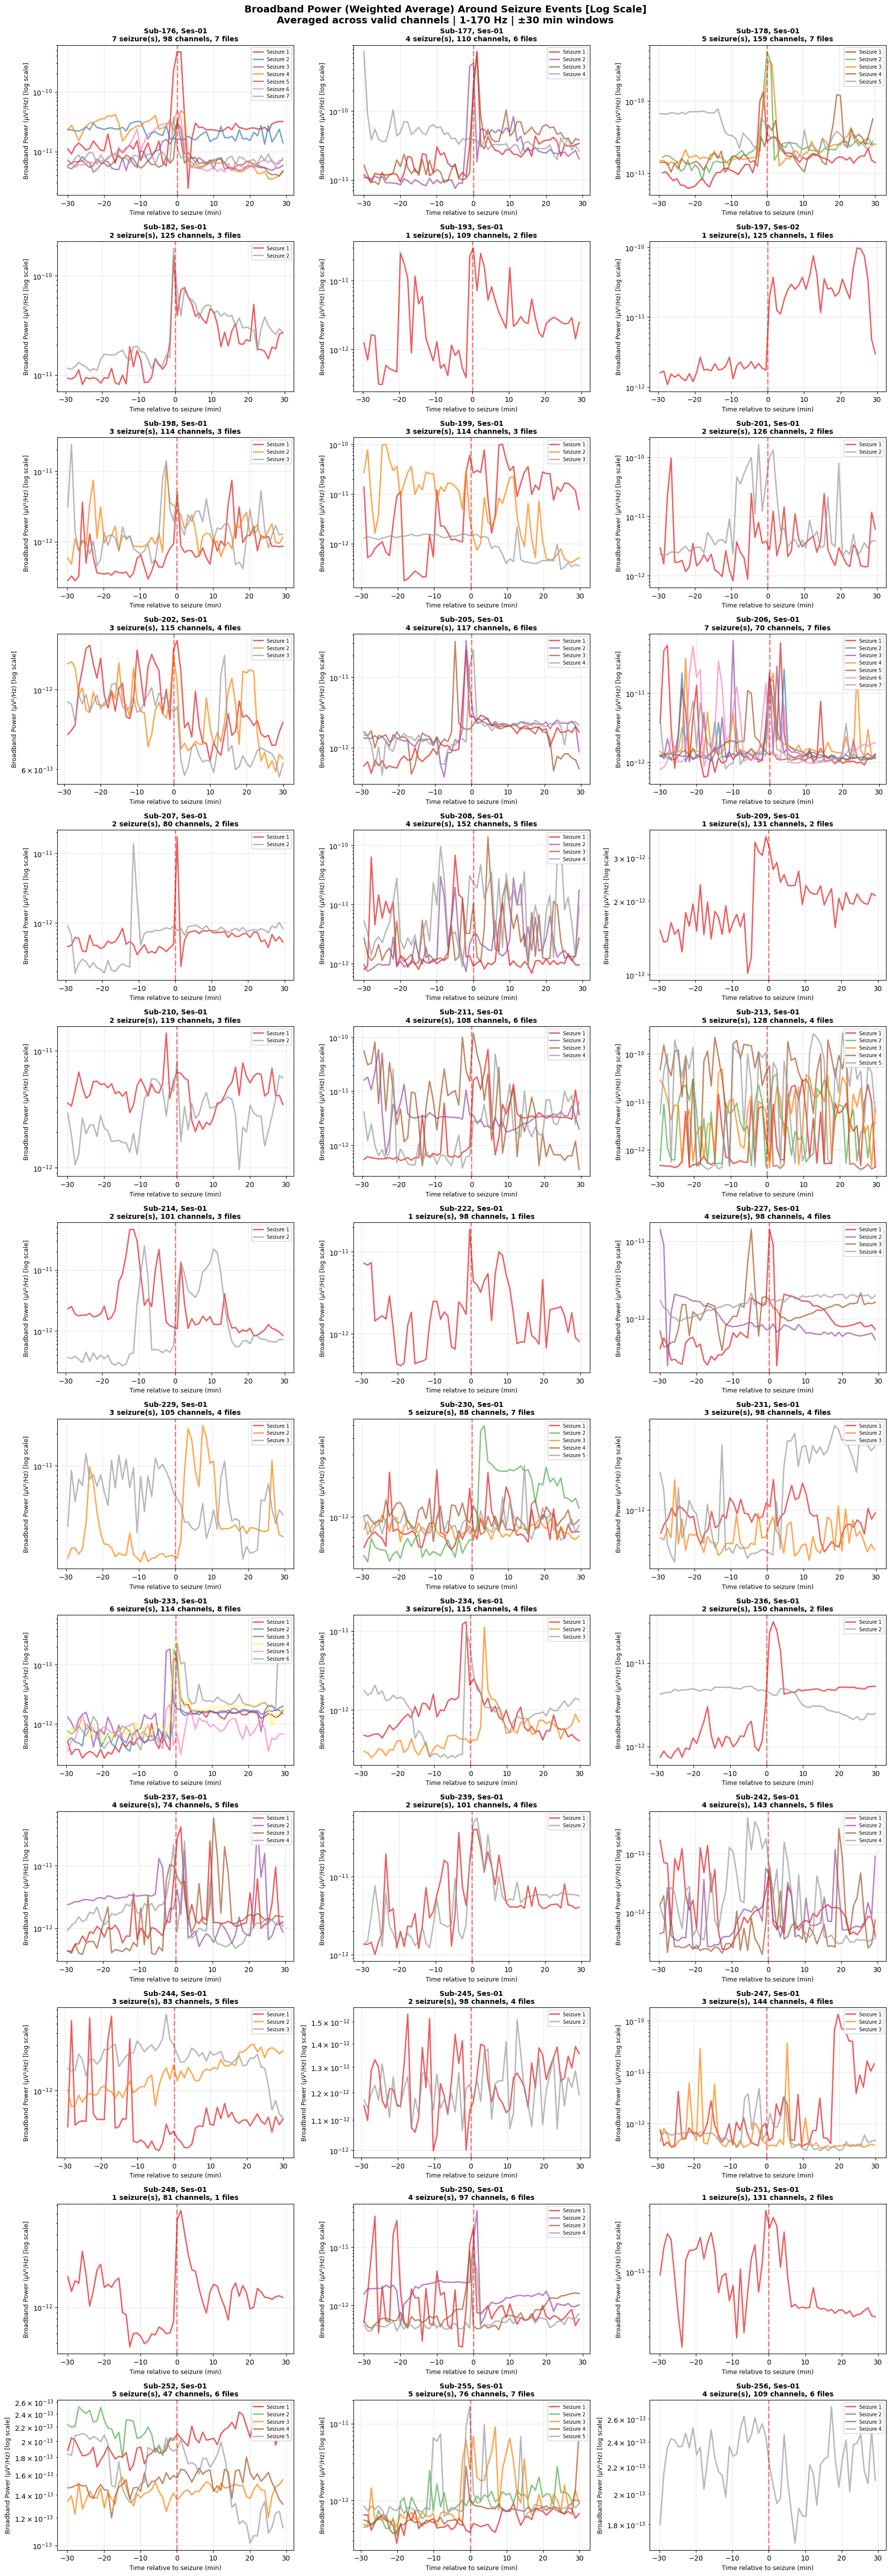

In [19]:
"""
Plot the data
You can run this cell multiple times with different parameters
without reloading the data!
"""

# CHOOSE: Weighted sum or weighted average?
USE_WEIGHTED_AVERAGE = True  # False = sum (μV²), True = average (μV²/Hz)

# Create plot
plot_all_participants_broadband(
    all_participant_data=all_participant_broadband_data,
    output_dir='./seizure_plots',
    window_minutes=30,
    n_cols=3,
    log_scale=True,
    use_weighted_average=USE_WEIGHTED_AVERAGE
)

